In [5]:
import sys
sys.path.insert(0, '/home/' + __import__('os').environ.get('USER','') + '/.local/lib/python3.9/site-packages')
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["HDFCBANK.NS", "RELIANCE.NS", "INFY.NS"]
data = yf.download(tickers, start="2023-01-01", end="2024-12-31")["Close"]
returns = data.pct_change().dropna()

print(returns.shape)

[*********************100%***********************]  3 of 3 completed

(489, 3)


In [6]:
num_portfolios = 5000
results = np.zeros((num_portfolios, 5))  # columns: weight1, weight2, weight3, volatility, sharpe

rf_annual = 0.065
rf_daily = rf_annual / 252

for i in range(num_portfolios):
    weights = np.random.random(3)
    weights = weights / np.sum(weights)  # make weights sum to 1
    
    port_returns = (returns * weights).sum(axis=1)
    ann_vol = port_returns.std() * (252 ** 0.5)
    sharpe = ((port_returns.mean() - rf_daily) / port_returns.std()) * (252 ** 0.5)
    
    results[i, 0] = weights[0]
    results[i, 1] = weights[1]
    results[i, 2] = weights[2]
    results[i, 3] = ann_vol
    results[i, 4] = sharpe

print("Simulation complete.")
print(results[:5])

Simulation complete.
[[ 0.3860756   0.1662211   0.4477033   0.15187971  0.05678008]
 [ 0.24973495  0.71531765  0.0349474   0.18268956  0.4288051 ]
 [ 0.44690165  0.05562013  0.49747822  0.15922757 -0.02477305]
 [ 0.48035138  0.40629232  0.1133563   0.15488022  0.29636809]
 [ 0.31775081  0.56566538  0.11658382  0.16408132  0.36994555]]


In [8]:
best_sharpe_idx = results[:, 4].argmax()
best_portfolio = results[best_sharpe_idx]

print("Best Sharpe ratio found:")
print(f"  HDFC Bank weight:  {best_portfolio[0]*100:.1f}%")
print(f"  Reliance weight:   {best_portfolio[1]*100:.1f}%")
print(f"  Infosys weight:    {best_portfolio[2]*100:.1f}%")
print(f"  Volatility:        {best_portfolio[3]*100:.2f}%")
print(f"  Sharpe ratio:      {best_portfolio[4]:.3f}")

Best Sharpe ratio found:
  HDFC Bank weight:  4.2%
  Reliance weight:   95.4%
  Infosys weight:    0.4%
  Volatility:        22.20%
  Sharpe ratio:      0.460


In [10]:
# Manually check: nearly all weight in Reliance
test_weights = np.array([0.048, 0.952, 0.001])  # HDFC, Reliance, Infosys

port_returns_test = (returns * test_weights).sum(axis=1)

print("Mean daily return:", port_returns_test.mean())
print("Daily std:", port_returns_test.std())
print("Annualised return:", port_returns_test.mean() * 252 * 100, "%")
print("Annualised vol:", port_returns_test.std() * (252**0.5) * 100, "%")

sharpe_test = ((port_returns_test.mean() - rf_daily) / port_returns_test.std()) * (252 ** 0.5)
print("Sharpe:", sharpe_test)


Mean daily return: 0.0006631191606037683
Daily std: 0.013962771473477433
Annualised return: 16.71060284721496 %
Annualised vol: 22.165212559228912 %
Sharpe: 0.4606589185612651


In [11]:
reliance_only = yf.download("RELIANCE.NS", start="2023-01-01", end="2024-12-31")["Close"]
reliance_returns = reliance_only.pct_change().dropna()

print("Reliance annualised return:", reliance_returns.mean().iloc[0] * 252 * 100, "%")
print("Reliance annualised vol:", reliance_returns.std().iloc[0] * (252**0.5) * 100, "%")

reliance_sharpe = ((reliance_returns.mean().iloc[0] - rf_daily) / reliance_returns.std().iloc[0]) * (252 ** 0.5)
print("Reliance Sharpe:", reliance_sharpe)


[*********************100%***********************]  1 of 1 completed

Reliance annualised return: 3.3641938990319593 %
Reliance annualised vol: 20.359225034948697 %
Reliance Sharpe: -0.15402384401101266


In [12]:
np.random.seed(42)

num_portfolios = 5000
results2 = np.zeros((num_portfolios, 5))

for i in range(num_portfolios):
    weights = np.random.random(3)
    weights = weights / np.sum(weights)
    
    port_returns = (returns * weights).sum(axis=1)
    ann_vol = port_returns.std() * (252 ** 0.5)
    sharpe = ((port_returns.mean() - rf_daily) / port_returns.std()) * (252 ** 0.5)
    
    results2[i, 0] = weights[0]
    results2[i, 1] = weights[1]
    results2[i, 2] = weights[2]
    results2[i, 3] = ann_vol
    results2[i, 4] = sharpe

best_idx2 = results2[:, 4].argmax()
print("With seed 42:")
print(f"  Weights: HDFC={results2[best_idx2,0]*100:.1f}%, Reliance={results2[best_idx2,1]*100:.1f}%, Infosys={results2[best_idx2,2]*100:.1f}%")
print(f"  Sharpe: {results2[best_idx2,4]:.3f}")

With seed 42:
  Weights: HDFC=4.2%, Reliance=94.2%, Infosys=1.7%
  Sharpe: 0.457


In [13]:
weights_check = np.array([0.048, 0.952, 0.001])

# Individual annualised returns (recompute fresh, cleanly)
data_check = yf.download(["HDFCBANK.NS", "RELIANCE.NS", "INFY.NS"], start="2023-01-01", end="2024-12-31")["Close"]
returns_check = data_check.pct_change().dropna()

individual_ann_returns = returns_check.mean() * 252 * 100
print("Individual annualised returns:")
print(individual_ann_returns)

print("\nWeighted average of individual returns (expected):")
weighted_avg = (individual_ann_returns.values * weights_check).sum()
print(weighted_avg, "%")

print("\nActual portfolio annualised return (from earlier):")
print("16.71 %")

[*********************100%***********************]  3 of 3 completed

Individual annualised returns:
Ticker
HDFCBANK.NS     7.781672
INFY.NS        17.157267
RELIANCE.NS     3.364194
dtype: float64

Weighted average of individual returns (expected):
16.71060284721496 %

Actual portfolio annualised return (from earlier):
16.71 %


In [8]:
# Individual Sharpe ratios
hdfc_ret = returns_check["HDFCBANK.NS"]
reliance_ret = returns_check["RELIANCE.NS"]
infy_ret = returns_check["INFY.NS"]

hdfc_sharpe = ((hdfc_ret.mean() - rf_daily) / hdfc_ret.std()) * (252**0.5)
reliance_sharpe = ((reliance_ret.mean() - rf_daily) / reliance_ret.std()) * (252**0.5)
infy_sharpe = ((infy_ret.mean() - rf_daily) / infy_ret.std()) * (252**0.5)

print("Individual Sharpe ratios:")
print(f"  HDFC Bank: {hdfc_sharpe:.3f}")
print(f"  Reliance:  {reliance_sharpe:.3f}")
print(f"  Infosys:   {infy_sharpe:.3f}")

# Naive weighted average of Sharpe ratios (WRONG approach, just to test)
naive_sharpe_avg = (hdfc_sharpe * 0.048) + (reliance_sharpe * 0.952) + (infy_sharpe * 0.001)
print(f"\nNaive weighted average of Sharpe ratios: {naive_sharpe_avg:.3f}")
print("Actual portfolio Sharpe (correct method): 0.460")

Individual Sharpe ratios:
  HDFC Bank: 0.065
  Reliance:  -0.154
  Infosys:   0.462

Naive weighted average of Sharpe ratios: -0.143
Actual portfolio Sharpe (correct method): 0.460


In [14]:
num_portfolios = 5000
results3 = np.zeros((num_portfolios, 5))

np.random.seed(42)

count = 0
attempts = 0

while count < num_portfolios and attempts < 50000:
    weights = np.random.random(3)
    weights = weights / np.sum(weights)
    attempts += 1
    
    # Constraint: no single stock above 50%
    if weights.max() > 0.50:
        continue
    
    port_returns = (returns * weights).sum(axis=1)
    ann_vol = port_returns.std() * (252 ** 0.5)
    sharpe = ((port_returns.mean() - rf_daily) / port_returns.std()) * (252 ** 0.5)
    
    results3[count, 0] = weights[0]
    results3[count, 1] = weights[1]
    results3[count, 2] = weights[2]
    results3[count, 3] = ann_vol
    results3[count, 4] = sharpe
    count += 1

print(f"Found {count} valid portfolios in {attempts} attempts")

best_idx3 = results3[:count, 4].argmax()
print("\nBest constrained portfolio (max 50% per stock):")
print(f"  HDFC Bank: {results3[best_idx3,0]*100:.1f}%")
print(f"  Reliance:  {results3[best_idx3,1]*100:.1f}%")
print(f"  Infosys:   {results3[best_idx3,2]*100:.1f}%")
print(f"  Volatility: {results3[best_idx3,3]*100:.2f}%")
print(f"  Sharpe:     {results3[best_idx3,4]:.3f}")

Found 5000 valid portfolios in 10031 attempts

Best constrained portfolio (max 50% per stock):
  HDFC Bank: 47.8%
  Reliance:  49.9%
  Infosys:   2.3%
  Volatility: 16.30%
  Sharpe:     0.360


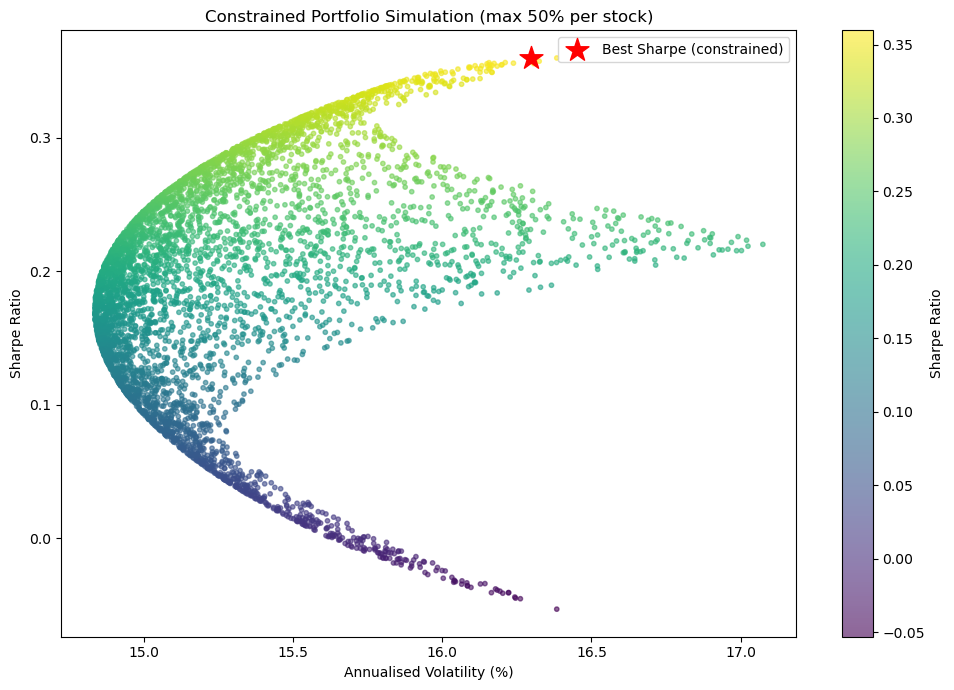

Saved.


In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(results3[:count, 3]*100, results3[:count, 4], c=results3[:count, 4], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(results3[best_idx3, 3]*100, results3[best_idx3, 4], color='red', marker='*', s=300, label='Best Sharpe (constrained)')
plt.xlabel("Annualised Volatility (%)")
plt.ylabel("Sharpe Ratio")
plt.title("Constrained Portfolio Simulation (max 50% per stock)")
plt.legend()
plt.tight_layout()
plt.savefig("efficient_frontier_constrained.png", dpi=150)
plt.show()
print("Saved.")